In [9]:
!pip install gguf transformers accelerate safetensors sentencepiece protobuf pillow huggingface_hub bitsandbytes -q
!pip install git+https://github.com/huggingface/diffusers --upgrade -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
!git clone https://github.com/Mann-E/gguf_inference
%cd gguf_inference

Cloning into 'gguf_inference'...
remote: Enumerating objects: 21, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 21 (delta 5), reused 21 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (21/21), 31.64 KiB | 531.00 KiB/s, done.
Resolving deltas: 100% (5/5), done.
/content/gguf_inference


In [3]:
!wget -c https://huggingface.co/unsloth/FLUX.2-klein-4B-GGUF/resolve/main/flux-2-klein-4b-Q4_0.gguf?download=true -O "flux-2-klein-4b-Q4_0.gguf"

--2026-07-10 22:03:26--  https://huggingface.co/unsloth/FLUX.2-klein-4B-GGUF/resolve/main/flux-2-klein-4b-Q4_0.gguf?download=true
Resolving huggingface.co (huggingface.co)... 18.164.174.23, 18.164.174.118, 18.164.174.55, ...
Connecting to huggingface.co (huggingface.co)|18.164.174.23|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.gcp.cdn.hf.co/xet-bridge-us/6969208b069de7a387ab4d1e/4d1d2474b292effbdc4aa3e0e26cad07bac0ab4600933682033e296fc3cf35d8?response-content-disposition=attachment%3B+filename*%3DUTF-8%27%27flux-2-klein-4b-Q4_0.gguf%3B+filename%3D%22flux-2-klein-4b-Q4_0.gguf%22%3B&user_id=public&X-Xet-Cas-Uid=public&Expires=1783724606&Policy=eyJTdGF0ZW1lbnQiOlt7IlJlc291cmNlIjoiaHR0cHM6Ly91cy5nY3AuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNjk2OTIwOGIwNjlkZTdhMzg3YWI0ZDFlLzRkMWQyNDc0YjI5MmVmZmJkYzRhYTNlMGUyNmNhZDA3YmFjMGFiNDYwMDkzMzY4MjAzM2UyOTZmYzNjZjM1ZDhcXD9yZXNwb25zZS1jb250ZW50LWRpc3Bvc2l0aW9uPSomdXNlcl9pZD1wdWJsaWMmWC1YZXQtQ2FzLVVpZD1wdWJsaWMiLCJD

In [5]:
!python gguf_inference.py flux-2-klein-4b-Q4_0.gguf --meta-only

GGUF         : flux-2-klein-4b-Q4_0.gguf
Architecture : flux
Tensors      : 149
Quants       : F32x60, Q4_0x80, BF16x9


In [18]:
!python gguf_inference.py flux-2-klein-4b-Q4_0.gguf \
  --model-type flux2_klein_4b \
  --vae-source pretrained \
  --te-mode bnb4 \
  --prompt "arabesque paper marbling painting of a mosque, architectural picture" \
  --cfg-scale 1.0 --steps 12 \
  --height 576 --width 1024 \
  --dtype bfloat16 --device cuda \
  --output mosque.png

------------------------------------------------------------------------
Flux.2 consumer-GPU inference (model-type–aware VAE)
  model_type   : flux2_klein_4b  family=flux2
  DiT GGUF     : flux-2-klein-4b-Q4_0.gguf
  base_config  : black-forest-labs/FLUX.2-klein-4B
  vae_source   : pretrained  path=None
  vae_class    : AutoencoderKLFlux2  z_ch=32
  te_mode      : bnb4  bnb=Qwen/Qwen3-4B
  prompt       : 'arabesque paper marbling painting of a mosque, architectural picture'
  cfg / steps  : 1.0 / 12
  size         : 576x1024
  dtype/device : torch.bfloat16 @ cuda  offload=True
  output       : mosque.png
------------------------------------------------------------------------
GGUF         : flux-2-klein-4b-Q4_0.gguf
Architecture : flux
Tensors      : 149
Quants       : F32x60, Q4_0x80, BF16x9
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be remove

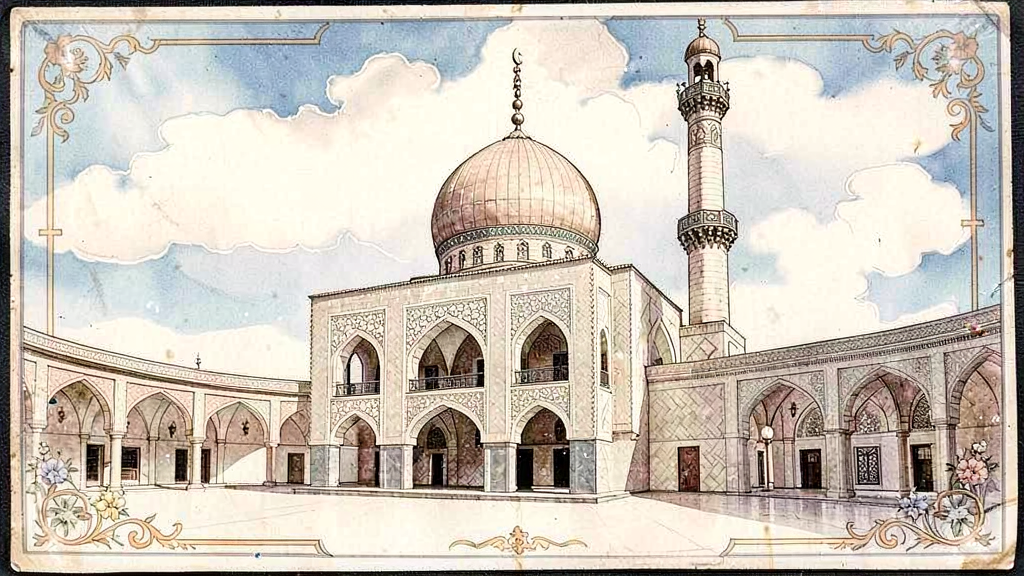

In [19]:
from PIL import Image

image = Image.open("mosque.png")

image